# UPA - 3.projekt

## 1.časť

In [3]:
#Modules import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import csv

In [12]:
# Load the dataframe
df = pd.read_csv("data.csv")
df.head()

,url,name,price,quantity_box,quantity_carton,color,material,dipping
0,https://www.ardon.cz/kombinovane-rukavice-ardo...,Kombinované rukavice ARDON®ELTON,69.43,12.0,72.0,žlutá,bavlna,NaN
1,https://www.ardon.cz/macene-rukavice-ardonsafe...,Máčené rukavice ARDON®PERRY UNI,15.67,NaN,NaN,NaN,NaN,NaN
2,https://www.ardon.cz/macene-rukavice-ardonsafe...,Máčené rukavice ARDON®RANDY,43.44,12.0,120.0,bílá,polyester,latex
3,https://www.ardon.cz/kombinovane-rukavice-ardo...,Kombinované rukavice ARDON®ELTON,60.50,12.0,72.0,žlutá,bavlna,NaN
4,https://www.ardon.cz/zimni-rukavice-ardon-r-ho...,Zimní rukavice ARDON®HOBBY REFLEX WINTER,104.15,12.0,120.0,reflexní,kůže,NaN


# Explorativná analýza

Pre zvolenú datovú sadu z prvého projektu najskôr prevedieme exploratívnu analýzu.

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   url              150 non-null    object 
 1   name             150 non-null    object 
 2   price            150 non-null    float64
 3   quantity_box     127 non-null    float64
 4   quantity_carton  127 non-null    float64
 5   color            140 non-null    object 
 6   material         142 non-null    object 
 7   dipping          83 non-null     object 
dtypes: float64(3), object(5)
memory usage: 9.5+ KB


Datová sada obsahuje 7 následujúcich atribútov:
url: unikátny identifikátor webovej stránky každej rukavice (kategorický)
name: Názov rukavíc (kategorický)
price: Cena rukavíc (kvantitatívny)
quantity_box: Počet rukavíc v balení (kvantitatívny)
quantity_carton Počet rukavíc v kartóne (kvantitatívny)
color: Farba rukavíc (kategorický)
material: Materiál z ktorého sú rukavice vyrobené (kategorický)
dipping: Máčanie rukavíc (kategorický)

Celkovo datová sada obsahuje 3 kvantitatívne a 5 kategorických atribútov.

V datovej sade sa nachádzajú aj chýbajúce hodnoty, kde najviac ich chýba v máčaní (dipping).

In [28]:
print(df.describe())

# Additional details: range, unique values, etc.
for column in df.select_dtypes(include=['float64', 'int64']).columns:
    print(f"\nColumn: {column}")
    print(f"Range: {df[column].min()} - {df[column].max()}")
    print(f"Unique values: {df[column].nunique()}")

             price  quantity_box  quantity_carton
count   150.000000    127.000000       127.000000
mean    143.714333     11.850394       132.881890
std     146.519208      1.031863        96.690524
min       5.960000      1.000000        60.000000
25%      43.937500     12.000000        72.000000
50%     108.005000     12.000000       120.000000
75%     195.245000     12.000000       144.000000
max    1188.190000     12.000000       600.000000

Column: price
Range: 5.96 - 1188.19
Unique values: 136

Column: quantity_box
Range: 1.0 - 12.0
Unique values: 3

Column: quantity_carton
Range: 60.0 - 600.0
Unique values: 9


Analyzovali sme kvantitatívne atribúty v dátovej sade s cieľom získať prehľad o ich štatistických vlastnostiach.

Atribúty ceny vykazujú variabilitu pravdepodobne v dôsledku prítomnosti odľahlých hodnôt. Atribút množstva v krabici vykazuje značne obmedzený počet unikátných hodnôt, tento fakt môžeme vidieť aj v kvantiloch, kedy obsahujú iba maximálnu hodnotu. Atribút množstva v kártóne má lepšiu variabilitu, avšak počet unikátnych hodnôt je tiež nízky.

Chýbajúce hodnoty pre počty sú rovnaké, kde obom atribútom chýba 23 hodnôt. 

In [29]:
# Check unique and most frequent values in categorical columns
for column in df.select_dtypes(include=['object']).columns:
    print(f"\nColumn: {column}")
    print(f"Unique values: {df[column].nunique()}")
    print("Most frequent values:")
    print(df[column].value_counts().head(5))


Column: url
Unique values: 150
Most frequent values:
url
https://www.ardon.cz/kombinovane-rukavice-ardon-r-elton-s-prodejni-etiketou    1
https://www.ardon.cz/atg-r-macene-rukavice-maxidry-r-56-425                    1
https://www.ardon.cz/atg-r-protirezne-rukavice-maxicut-r-oiltm-44-305          1
https://www.ardon.cz/atg-r-protirezne-rukavice-maxicut-r-oiltm-44-504          1
https://www.ardon.cz/atg-r-protirezne-rukavice-maxicut-r-oiltm-44-505          1
Name: count, dtype: int64

Column: name
Unique values: 147
Most frequent values:
name
Kombinované rukavice ARDON®ELTON                 2
Svářečské rukavice ARDON®COY                     2
Máčené rukavice ARDON®PERRY UNI                  2
Zimní rukavice ARDON®Winfine                     1
ATG® protiřezné rukavice MaxiCut® Oil™ 44-305    1
Name: count, dtype: int64

Column: color
Unique values: 22
Most frequent values:
color
modrá     28
šedá      25
zelená    19
bílá      15
žlutá     12
Name: count, dtype: int64

Column: material


Teraz zanalyzujeme kategorické premenné.

Atribút url má všetky hodnoty unikátne, čo potvrdzuje, že slúži ako jednoznačný identifikátor každého produktu v dátovej sade.
Atribút názvu obsahuje tri duplikátne hodnoty, ktoré predstavujú rovnaké produkty. Po bližšej analýze sme zistili, že tieto produkty majú niektoré atribúty, ako napríklad cena, rozdielne, čo môže naznačovať odlišné varianty alebo rôzne balenia toho istého produktu.
Ostatné atribúty majú dobrú variabilitu s dostatočným počtom unikátnych hodnôt.

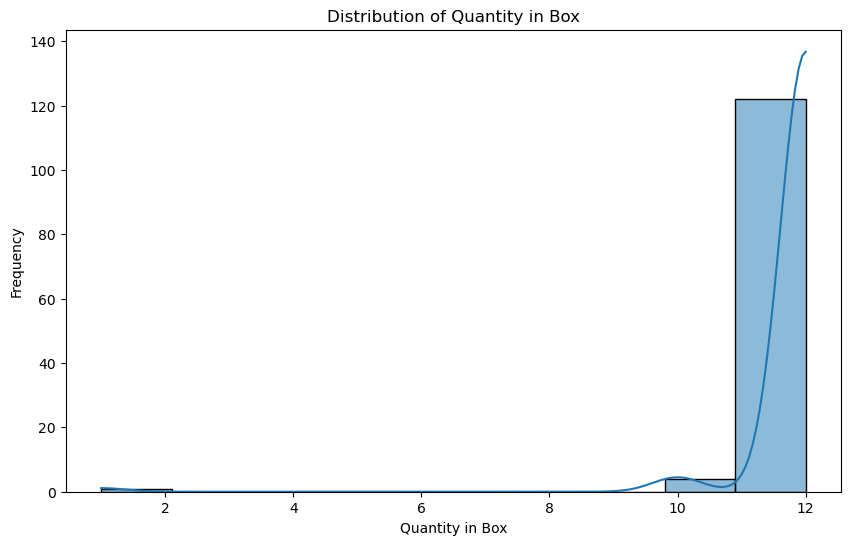

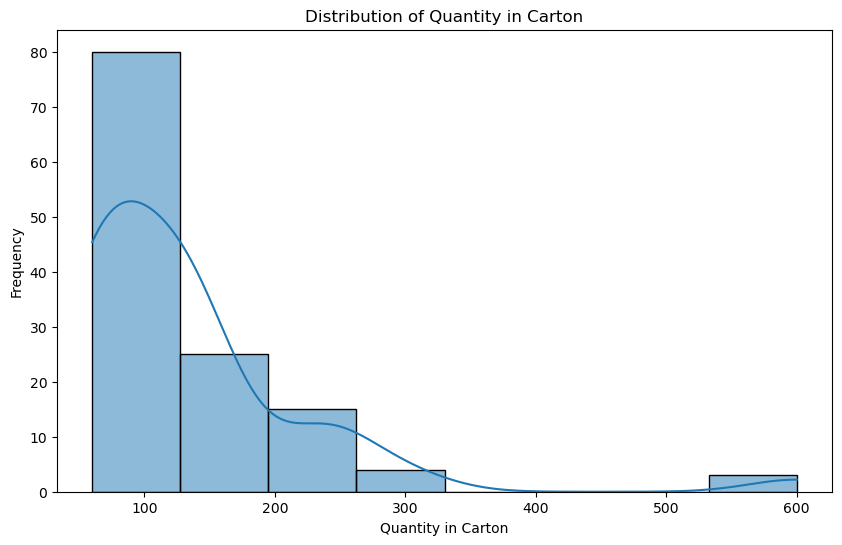

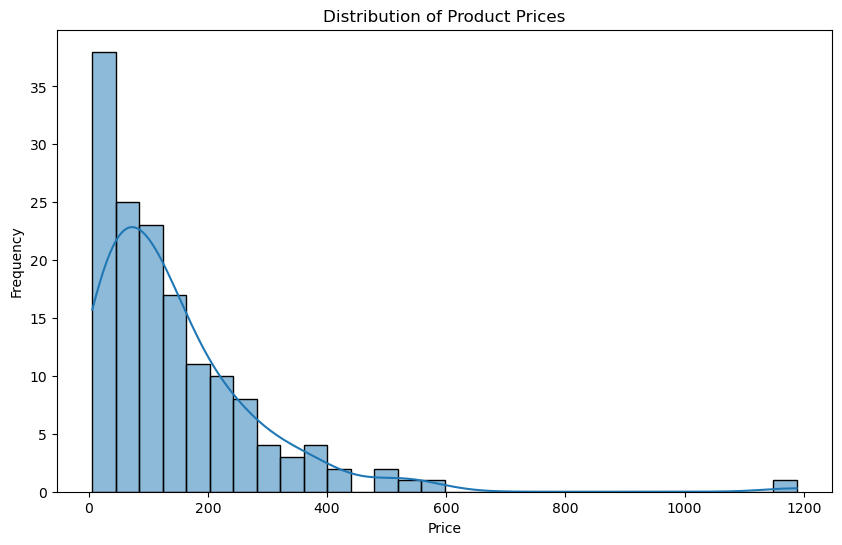

In [52]:
plt.figure(figsize=(10, 6))
sns.histplot(df['quantity_box'], kde=True, bins=10)
plt.title('Distribution of Quantity in Box')
plt.xlabel('Quantity in Box')
plt.ylabel('Frequency')
plt.show()

# Histogram for 'quantity_in_carton'
plt.figure(figsize=(10, 6))
sns.histplot(df['quantity_carton'], kde=True, bins=8)
plt.title('Distribution of Quantity in Carton')
plt.xlabel('Quantity in Carton')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, bins=30)
plt.title('Distribution of Product Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()